# Uses 'Kaggle_TicTacToe.csv', 'aug3_player1_data.csv', and 'aug3_player2_data.csv.csv'
data from https://www.kaggle.com/datasets/fabdelja/tictactoe?resource=download

In [31]:
import pandas as pd
import numpy as np

# read in the dataset and change the 'Class' column to 'Outcome'
df = pd.read_csv("Kaggle_TicTacToe.csv") #.head(50)
df1 = df.rename({'CLASS' : 'OUTCOME'}, axis=1)

# dropped these columns because there cannot be more than 5 moves in a game of tic-tac-toe
df2 = df1.drop(['MOVE6', 'MOVE7'], axis=1)

# made the values 1 less than they should be
df3 = df2.replace("win", 0).replace("loss", -2).replace("draw", -1).replace("?", -1) 
df4 = df3.astype(int).add(1)

# split the dataset into two because one line represents the first player, and the next represents the second player
player_one = df4[df4.index % 2 == 0].head(100) 
player_two = df4[df4.index % 2 == 1].head(100)

In [32]:
data = player_one.values.tolist()
data2 = player_two.values.tolist()

In [33]:
# sort the datasets based on the outcome (win, loss, draw) and the number of decisions made during each game
def sortLast(val):
    return val[-1]

data.sort(key=sortLast)
data2.sort(key=sortLast)

In [34]:
import csv

header = ['Outcome', 'Decision1', 'Decision2', 'Decision3', 'Decision4', 'Decision5']
final = []

for row in data: 
    final.append([row[-1], int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4])])

with open('aug3_player1_data.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(final)

In [35]:
import csv

header = ['Outcome', 'Decision1', 'Decision2', 'Decision3', 'Decision4', 'Decision5']
final2 = []

for row in data2: 
    final2.append([row[-1], int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4])])
    
with open('aug3_player2_data.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(final2)

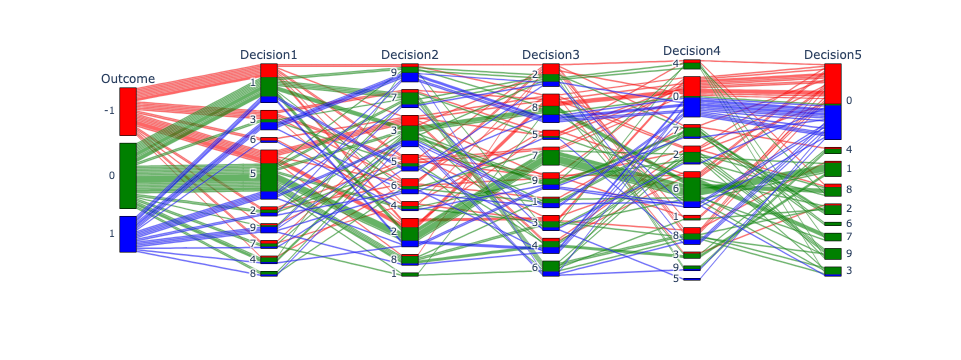

In [36]:
import pandas as pd
import numpy as np
import plotly.express as px

new_data = pd.read_csv("aug3_player1_data.csv")
fig = px.parallel_categories(new_data, color = "Outcome", color_continuous_scale=["red", "green", "blue"]) 
fig.update_coloraxes(showscale=False)
fig.show()

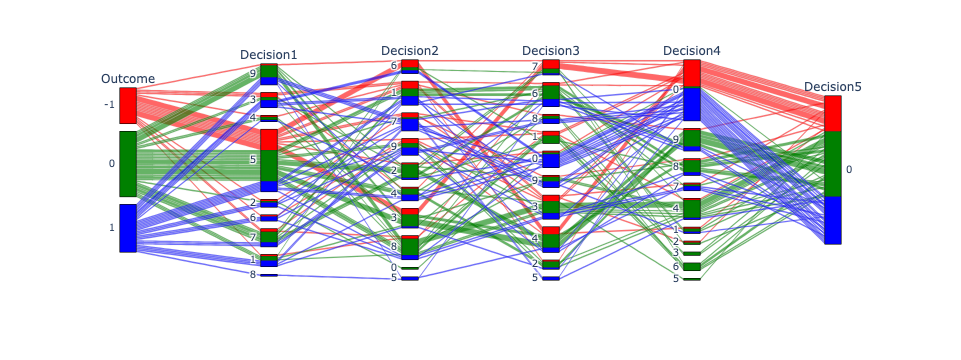

In [37]:
import pandas as pd
import numpy as np
import plotly.express as px

new_data = pd.read_csv("aug3_player2_data.csv")
fig = px.parallel_categories(new_data, color = "Outcome", color_continuous_scale=["red", "green", "blue"]) 
fig.update_coloraxes(showscale=False)
fig.show()